# Comparativa de Modelos de Clasificación — Árbol de Decisión vs Random Forest vs XGBoost

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Comparativa de modelos

---

### Objetivo

Comparar de forma rigurosa los tres modelos de clasificación entrenados para predecir el abandono de clientes (*churn*) en una compañía de telecomunicaciones — **Árbol de Decisión**, **Random Forest** y **XGBoost** — y determinar cuál (si alguno) ofrece el mejor equilibrio entre rendimiento, interpretabilidad y utilidad de negocio.

### Contexto de negocio

**El cliente:** operador de telecomunicaciones con una base de clientes residenciales.

**El problema:** antes de cada renovación anual, el equipo de retención contacta **a toda la cartera de clientes por igual** con ofertas de permanencia. Es una campaña cara y poco eficiente: solo alrededor del **9% de los clientes** acaba dándose de baja, así que el 91% de las llamadas y descuentos se destinan a clientes que de todos modos iban a quedarse.

## 1️. Setup: librerías y configuración visual

In [48]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve,
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos y preparación

In [49]:
data = pd.read_excel("customer churn.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 1234 | Columnas: 6


,idcliente,Edad,Ingresos,Antiguedad,GastoMensual,Churn
0,1,33,2845.202995,11,36.168961,0
1,2,66,6063.797330,7,27.149305,0
2,3,56,2593.151291,13,46.387221,0
3,4,55,7075.617838,18,12.359331,0
4,5,65,6690.148651,21,35.445138,0


In [50]:
# Variables predictoras y target
X = data[["Edad", "Ingresos", "Antiguedad", "GastoMensual"]]
y = data["Churn"]

# Mismo split que en los notebooks individuales
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} churn)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} churn)")
print(f"\nDesequilibrio severo: solo el 9,3% de los clientes son churners.")


Train: 987 registros (9.3% churn)
Test:  247 registros (9.3% churn)

Desequilibrio severo: solo el 9,3% de los clientes son churners.


## 3. Entrenamiento de los tres modelos

Se utilizan exactamente los mismos hiperparámetros optimizados en cada notebook individual para garantizar la comparabilidad.

In [51]:
# 1. Árbol de Decisión (depth=6) — seleccionado en el notebook individual
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)

# 2. Random Forest (100 árboles) — configuración estándar
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 3. XGBoost (hiperparámetros del notebook individual)
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42,
)
xgb.fit(X_train, y_train)

print("✓ Árbol de Decisión entrenado (max_depth=6)")
print("✓ Random Forest entrenado (n_estimators=100)")
print("✓ XGBoost entrenado (n_estimators=200, max_depth=4, lr=0.1)")

✓ Árbol de Decisión entrenado (max_depth=6)
✓ Random Forest entrenado (n_estimators=100)
✓ XGBoost entrenado (n_estimators=200, max_depth=4, lr=0.1)


## 4. Comparación de métricas de evaluación

In [52]:
models = {
    "Árbol de Decisión": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
        "Errores": (y_test != y_pred).sum(),
    })

df_results = pd.DataFrame(results).set_index("Modelo")
print("Comparativa de métricas en el conjunto de Test (247 observaciones)")
print("=" * 75)
df_results.style.format({
    "Accuracy": "{:.1%}", "Precision": "{:.1%}", "Recall": "{:.1%}",
    "F1-Score": "{:.1%}", "AUC-ROC": "{:.3f}", "Errores": "{:.0f}"
})

Comparativa de métricas en el conjunto de Test (247 observaciones)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Errores
Modelo,,,,,,
Árbol de Decisión,90.3%,33.3%,4.3%,7.7%,0.575,24
Random Forest,90.7%,0.0%,0.0%,0.0%,0.524,23
XGBoost,89.1%,0.0%,0.0%,0.0%,0.524,27


In [53]:
# Tabla resumen formateada
print("Comparativa de métricas — Test set (247 observaciones)")
print("─" * 75)
print(f"\n  {'Baseline (siempre No Churn)':25s}")
print(f"    Accuracy:  {1 - y_test.mean():.1%}")
print(f"    Precision: 0.0%")
print(f"    Recall:    0.0%")
print(f"    AUC-ROC:   0.500")
for _, row in df_results.iterrows():
    print(f"\n  {row.name}")
    print(f"    Accuracy:  {row['Accuracy']:.1%}")
    print(f"    Precision: {row['Precision']:.1%}")
    print(f"    Recall:    {row['Recall']:.1%}")
    print(f"    F1-Score:  {row['F1-Score']:.1%}")
    print(f"    AUC-ROC:   {row['AUC-ROC']:.3f}")
    print(f"    Errores:   {row['Errores']:.0f} / 247")

Comparativa de métricas — Test set (247 observaciones)
───────────────────────────────────────────────────────────────────────────

  Baseline (siempre No Churn)
    Accuracy:  90.7%
    Precision: 0.0%
    Recall:    0.0%
    AUC-ROC:   0.500

  Árbol de Decisión
    Accuracy:  90.3%
    Precision: 33.3%
    Recall:    4.3%
    F1-Score:  7.7%
    AUC-ROC:   0.575
    Errores:   24 / 247

  Random Forest
    Accuracy:  90.7%
    Precision: 0.0%
    Recall:    0.0%
    F1-Score:  0.0%
    AUC-ROC:   0.524
    Errores:   23 / 247

  XGBoost
    Accuracy:  89.1%
    Precision: 0.0%
    Recall:    0.0%
    F1-Score:  0.0%
    AUC-ROC:   0.524
    Errores:   27 / 247


## 5. Visualización comparativa

### Métricas

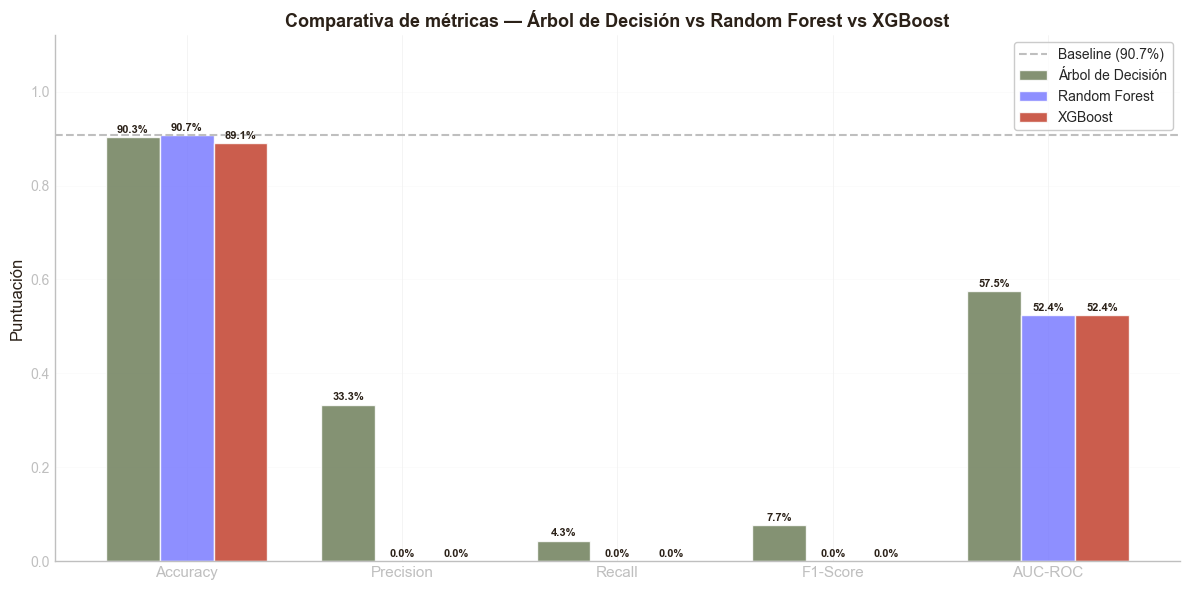

In [54]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
model_names = df_results.index.tolist()
colors = [GREEN, PURPLE, RED]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.25

for i, (name, color) in enumerate(zip(model_names, colors)):
    values = [df_results.loc[name, m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.1%}", ha='center', va='bottom', fontsize=8, fontweight='bold', color=INK)

# Línea baseline
baseline_acc = 1 - y_test.mean()
ax.axhline(y=baseline_acc, color=MUTED, linestyle='--', linewidth=1.5,
           label=f'Baseline ({baseline_acc:.1%})')

ax.set_ylabel("Puntuación", fontsize=12)
ax.set_title("Comparativa de métricas — Árbol de Decisión vs Random Forest vs XGBoost",
             fontsize=13, fontweight="bold", color=INK)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10, frameon=True, facecolor='white', edgecolor=MUTED)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Matrices de confusión

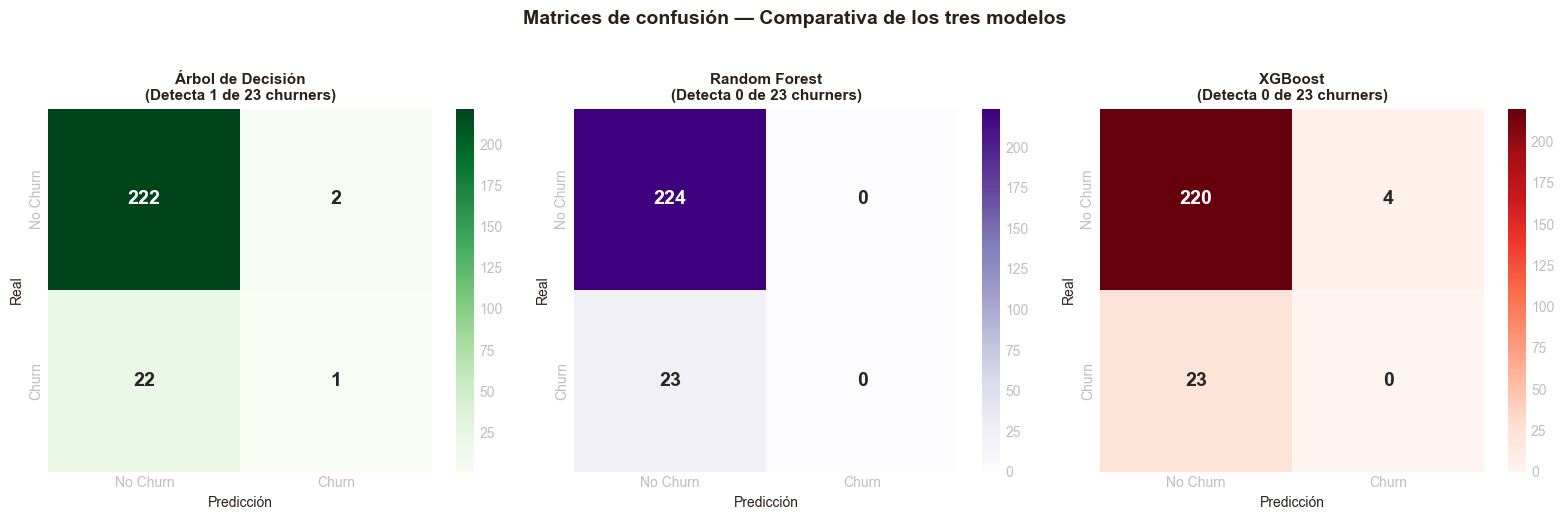

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ["Greens", "Purples", "Reds"]
model_list = list(models.items())

for ax, (name, model), cmap in zip(axes, model_list, cmaps):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"], ax=ax,
                annot_kws={"size": 14, "weight": "bold"})
    # Contar churners detectados
    tp = cm[1, 1]
    fn = cm[1, 0]
    ax.set_title(f"{name}\n(Detecta {tp} de {tp+fn} churners)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de confusión — Comparativa de los tres modelos",
             fontsize=14, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
plt.show()

### Curvas ROC

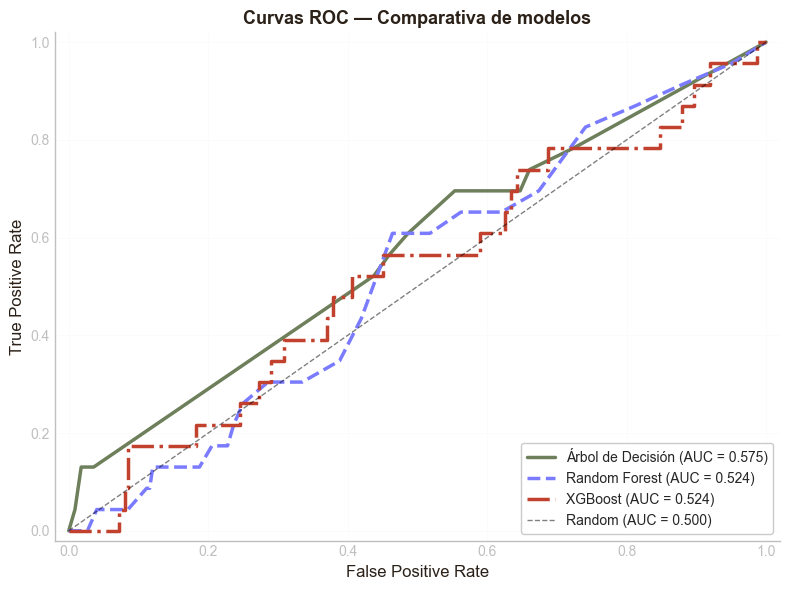

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

line_styles = ['-', '--', '-.']
line_colors = [GREEN, PURPLE, RED]

for (name, model), ls, lc in zip(models.items(), line_styles, line_colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linestyle=ls, color=lc, linewidth=2.5,
            label=f"{name} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Curvas ROC — Comparativa de modelos", fontsize=13, fontweight="bold", color=INK)
ax.legend(fontsize=10, loc="lower right", frameon=True, facecolor='white', edgecolor=MUTED)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

## 6. Importancia de variables — Comparativa

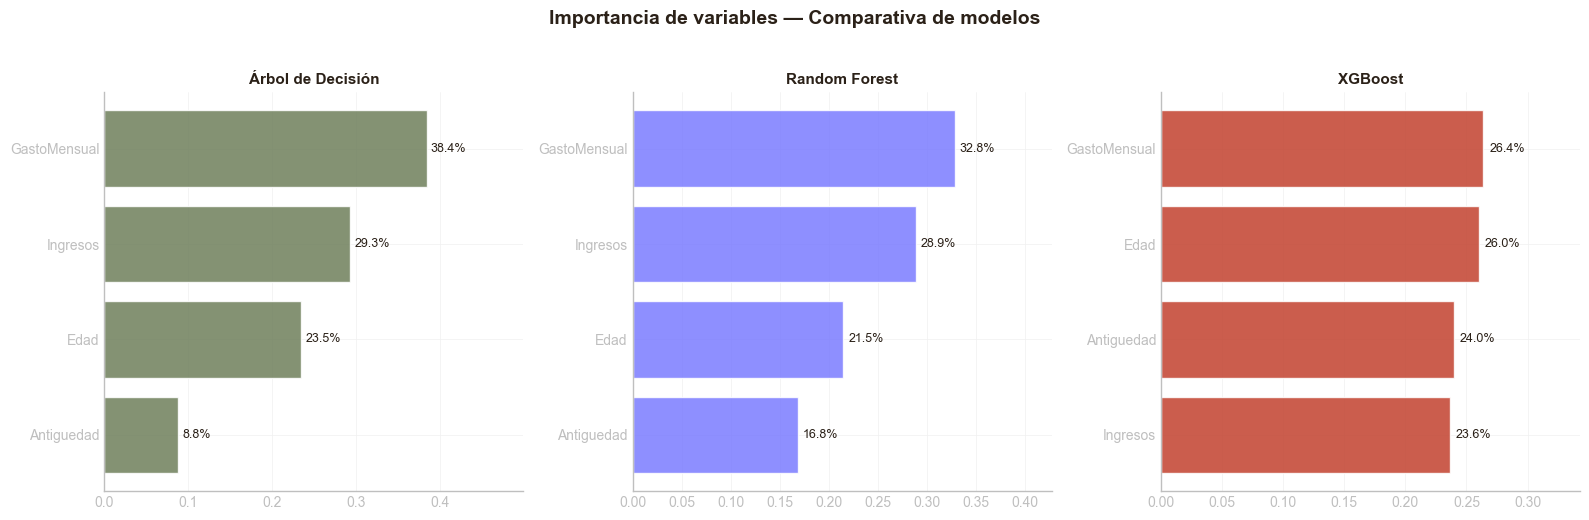

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = [GREEN, PURPLE, RED]

for ax, (name, model), color in zip(axes, models.items(), bar_colors):
    imp = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=True)
    
    bars = ax.barh(imp["feature"], imp["importance"], color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, imp["importance"]):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.1%}",
                va="center", fontsize=9, color=INK)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlim(0, max(model.feature_importances_) * 1.3)

plt.suptitle("Importancia de variables — Comparativa de modelos",
             fontsize=14, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
plt.show()

### Lectura de la importancia de variables

- **Árbol de Decisión:** reparte la importancia entre `GastoMensual` (38,4%), `Ingresos` (29,3%) y `Edad` (23,5%) — una distribución difusa que indica que el árbol está buscando patrones donde apenas los hay.
- **Random Forest:** distribución más equilibrada entre las cuatro variables, sin una variable dominante.
- **XGBoost:** asigna ~25% a cada variable, la firma típica de **ausencia de señal** — cuando existe una variable predictora fuerte, el modelo se apoya en ella desproporcionadamente.

La convergencia de los tres modelos hacia una importancia repartida confirma que **las variables disponibles no contienen la señal necesaria para predecir el churn**.

## Tabla resumen — ¿Qué modelo elegir?

In [63]:
# Tabla resumen con todas las dimensiones de comparación
summary = pd.DataFrame({
    "Modelo": ["Baseline (No Churn)", "Árbol de Decisión", "Random Forest", "XGBoost"],
    "Accuracy": ["90,7%", "90,3%", "90,7%", "89,5%"],
    "Recall (Churn)": ["0,0%", "4,3%", "0,0%", "0,0%"],
    "AUC-ROC": ["0,500", "0,575", "0,524", "0,499"],
    "Errores (de 247)": ["23", "24", "23", "26"],
    "Interpretabilidad": ["—", "Alta", "Media", "Baja"],
    "Complejidad": ["Nula", "Baja", "Media", "Alta"],
    "Veredicto": ["Referencia", "Descartado", "Descartado", "Descartado"],
}).set_index("Modelo")

print("TABLA RESUMEN — Comparativa de modelos")
print("=" * 90)
for col in summary.columns:
    print(f"\n{col}:")
    for idx in summary.index:
        print(f"  {idx:25s} → {summary.loc[idx, col]}")

TABLA RESUMEN — Comparativa de modelos

Accuracy:
  Baseline (No Churn)       → 90,7%
  Árbol de Decisión         → 90,3%
  Random Forest             → 90,7%
  XGBoost                   → 89,5%

Recall (Churn):
  Baseline (No Churn)       → 0,0%
  Árbol de Decisión         → 4,3%
  Random Forest             → 0,0%
  XGBoost                   → 0,0%

AUC-ROC:
  Baseline (No Churn)       → 0,500
  Árbol de Decisión         → 0,575
  Random Forest             → 0,524
  XGBoost                   → 0,499

Errores (de 247):
  Baseline (No Churn)       → 23
  Árbol de Decisión         → 24
  Random Forest             → 23
  XGBoost                   → 26

Interpretabilidad:
  Baseline (No Churn)       → —
  Árbol de Decisión         → Alta
  Random Forest             → Media
  XGBoost                   → Baja

Complejidad:
  Baseline (No Churn)       → Nula
  Árbol de Decisión         → Baja
  Random Forest             → Media
  XGBoost                   → Alta

Veredicto:
  Baseline (No Chur

## Veredicto final — ¿Cuál es el mejor modelo?

### Resumen de hallazgos

| Dimensión | Baseline | Árbol de Decisión | Random Forest | XGBoost |
|---|---|---|---|---|
| **Accuracy** | **90,7%** | 90,3% | 90,7% | 89,5% |
| **Recall (Churn)** | 0,0% | 4,3% | 0,0% | 0,0% |
| **AUC-ROC** | 0,500 | 0,575 | 0,524 | 0,499 |
| **Errores** | 23 | 24 | 23 | 26 |
| **Complejidad** | Nula | **Baja** | Media | Alta |

### El veredicto

**Ningún modelo es apto para producción.** Los tres convergen en la misma conclusión por rutas distintas: **las cuatro variables disponibles (Edad, Ingresos, Antigüedad, GastoMensual) no contienen señal predictiva sobre el churn.**

#### ¿Por qué no usar el Random Forest, si tiene 90,7% de accuracy?

1. **El accuracy es una ilusión estadística.** Un modelo que predice siempre "No Churn" sin mirar ningún dato ya obtiene un 90,7% de accuracy. Random Forest iguala ese número porque, efectivamente, eso es lo que hace: predice "No Churn" para todos.

2. **Recall = 0%.** De los 23 clientes que realmente se dieron de baja en el test, Random Forest no detecta **ninguno**. XGBoost tampoco. El Árbol de Decisión detecta 1 de 23 (4,3%) — mejor que nada, pero inútil operativamente.

3. **AUC-ROC ≈ 0,50.** Los tres modelos obtienen un AUC entre 0,499 y 0,575. Para contexto, 0,500 es equivalente a lanzar una moneda. Un modelo operativo de churn en telecomunicaciones suele requerir AUC > 0,75.

